In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv(r"C:\Users\Nishant\Downloads\microservice_performance.csv")

In [3]:
df

,CPU_Usage_Percent,Memory_Usage_MB,Disk_IO_MBps,Network_IO_MBps,Response_Time_ms,Request_Count_per_Min,Error_Rate_Percent,Availability_Percent,Latency_ms
0,64.93,1573.05,137.41,41.55,137.53,5176.77,0.45,98.76,54.10
1,52.23,1834.15,134.17,115.60,271.14,4884.61,5.92,98.70,76.57
2,67.95,1629.83,73.17,153.04,162.16,6713.22,6.28,100.00,73.98
3,85.46,2125.29,148.98,211.97,188.15,7759.10,1.66,98.74,66.08
4,50.32,2886.02,45.50,281.93,244.57,6236.32,0.42,99.11,67.90
...,...,...,...,...,...,...,...,...,...
9995,81.02,2319.48,91.14,289.57,185.11,3736.66,1.27,99.99,118.55
9996,15.03,3012.16,192.23,221.20,177.76,3021.72,0.93,99.29,76.22
9997,40.89,2312.85,94.93,249.32,225.01,5253.82,2.11,99.71,82.39
9998,64.92,3247.47,25.38,265.17,203.87,1072.45,0.80,99.03,128.57


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CPU_Usage_Percent      10000 non-null  float64
 1   Memory_Usage_MB        10000 non-null  float64
 2   Disk_IO_MBps           10000 non-null  float64
 3   Network_IO_MBps        10000 non-null  float64
 4   Response_Time_ms       10000 non-null  float64
 5   Request_Count_per_Min  10000 non-null  float64
 6   Error_Rate_Percent     10000 non-null  float64
 7   Availability_Percent   10000 non-null  float64
 8   Latency_ms             10000 non-null  float64
dtypes: float64(9)
memory usage: 703.3 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CPU_Usage_Percent,10000.0,54.890931,19.761480,1.00,41.5475,54.945,68.4225,100.00
Memory_Usage_MB,10000.0,2058.297828,698.231255,128.00,1584.5950,2059.095,2533.7075,5183.36
Disk_IO_MBps,10000.0,119.498894,49.241882,1.00,84.9925,119.710,153.1925,304.58
Network_IO_MBps,10000.0,199.596453,79.789891,1.00,144.4300,199.170,254.3225,498.23
Response_Time_ms,10000.0,181.531841,87.835492,5.00,120.2350,180.860,241.5425,498.29
Request_Count_per_Min,10000.0,5005.547995,1810.334150,100.00,3781.5350,5014.805,6243.5000,11741.68
Error_Rate_Percent,10000.0,2.009343,1.980950,0.00,0.5800,1.420,2.8100,17.85
Availability_Percent,10000.0,99.150253,0.624314,96.08,98.7200,99.190,99.6700,100.00
Latency_ms,10000.0,95.642749,39.892944,1.00,69.1725,95.460,122.2025,248.19


In [6]:
df.isnull().sum()

CPU_Usage_Percent        0
Memory_Usage_MB          0
Disk_IO_MBps             0
Network_IO_MBps          0
Response_Time_ms         0
Request_Count_per_Min    0
Error_Rate_Percent       0
Availability_Percent     0
Latency_ms               0
dtype: int64

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 0


In [8]:
df.columns

Index(['CPU_Usage_Percent', 'Memory_Usage_MB', 'Disk_IO_MBps',
       'Network_IO_MBps', 'Response_Time_ms', 'Request_Count_per_Min',
       'Error_Rate_Percent', 'Availability_Percent', 'Latency_ms'],
      dtype='object')

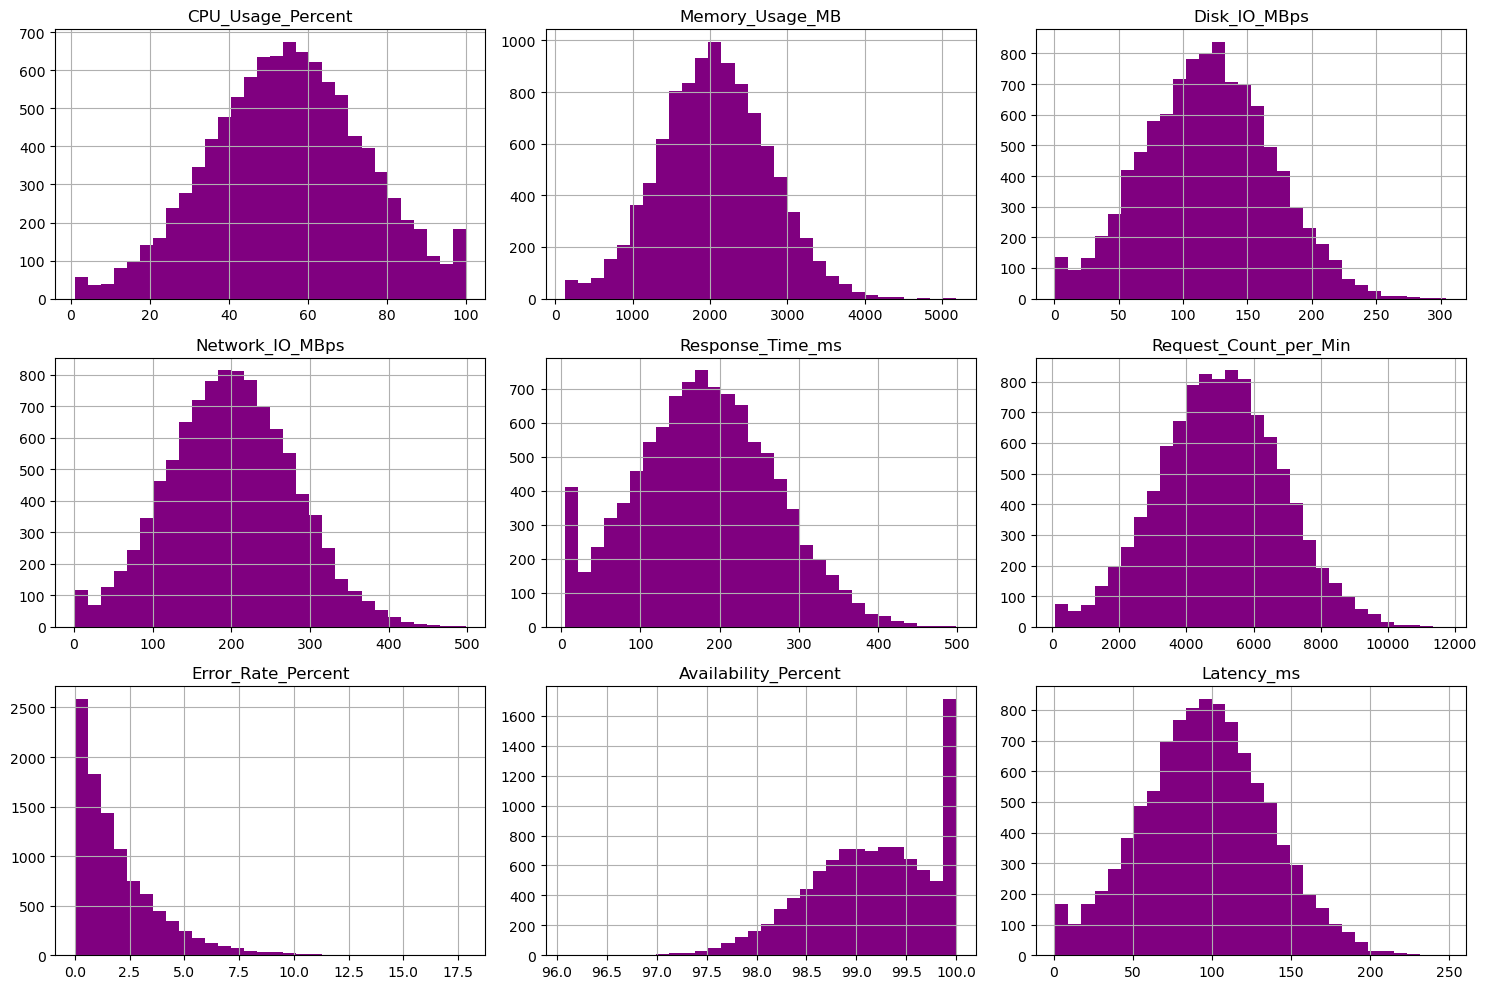

In [9]:
df.hist(figsize=(15,10), bins=30, color='Purple')

plt.tight_layout()
plt.show()

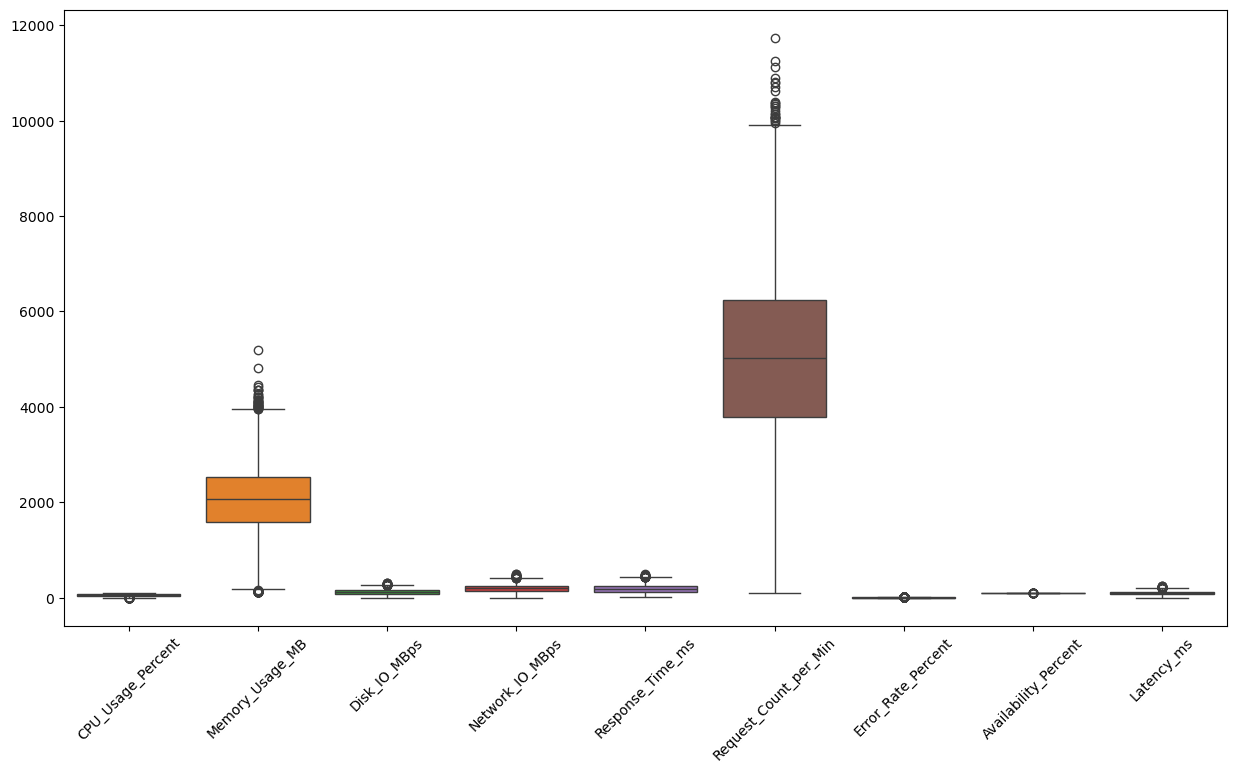

In [10]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.show()

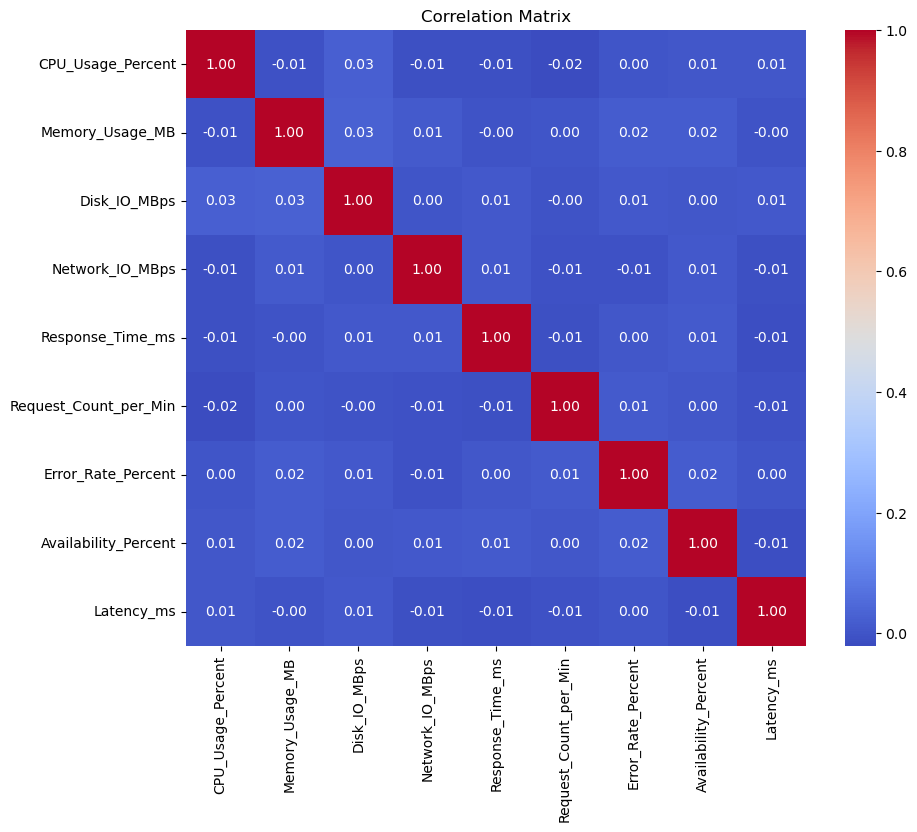

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

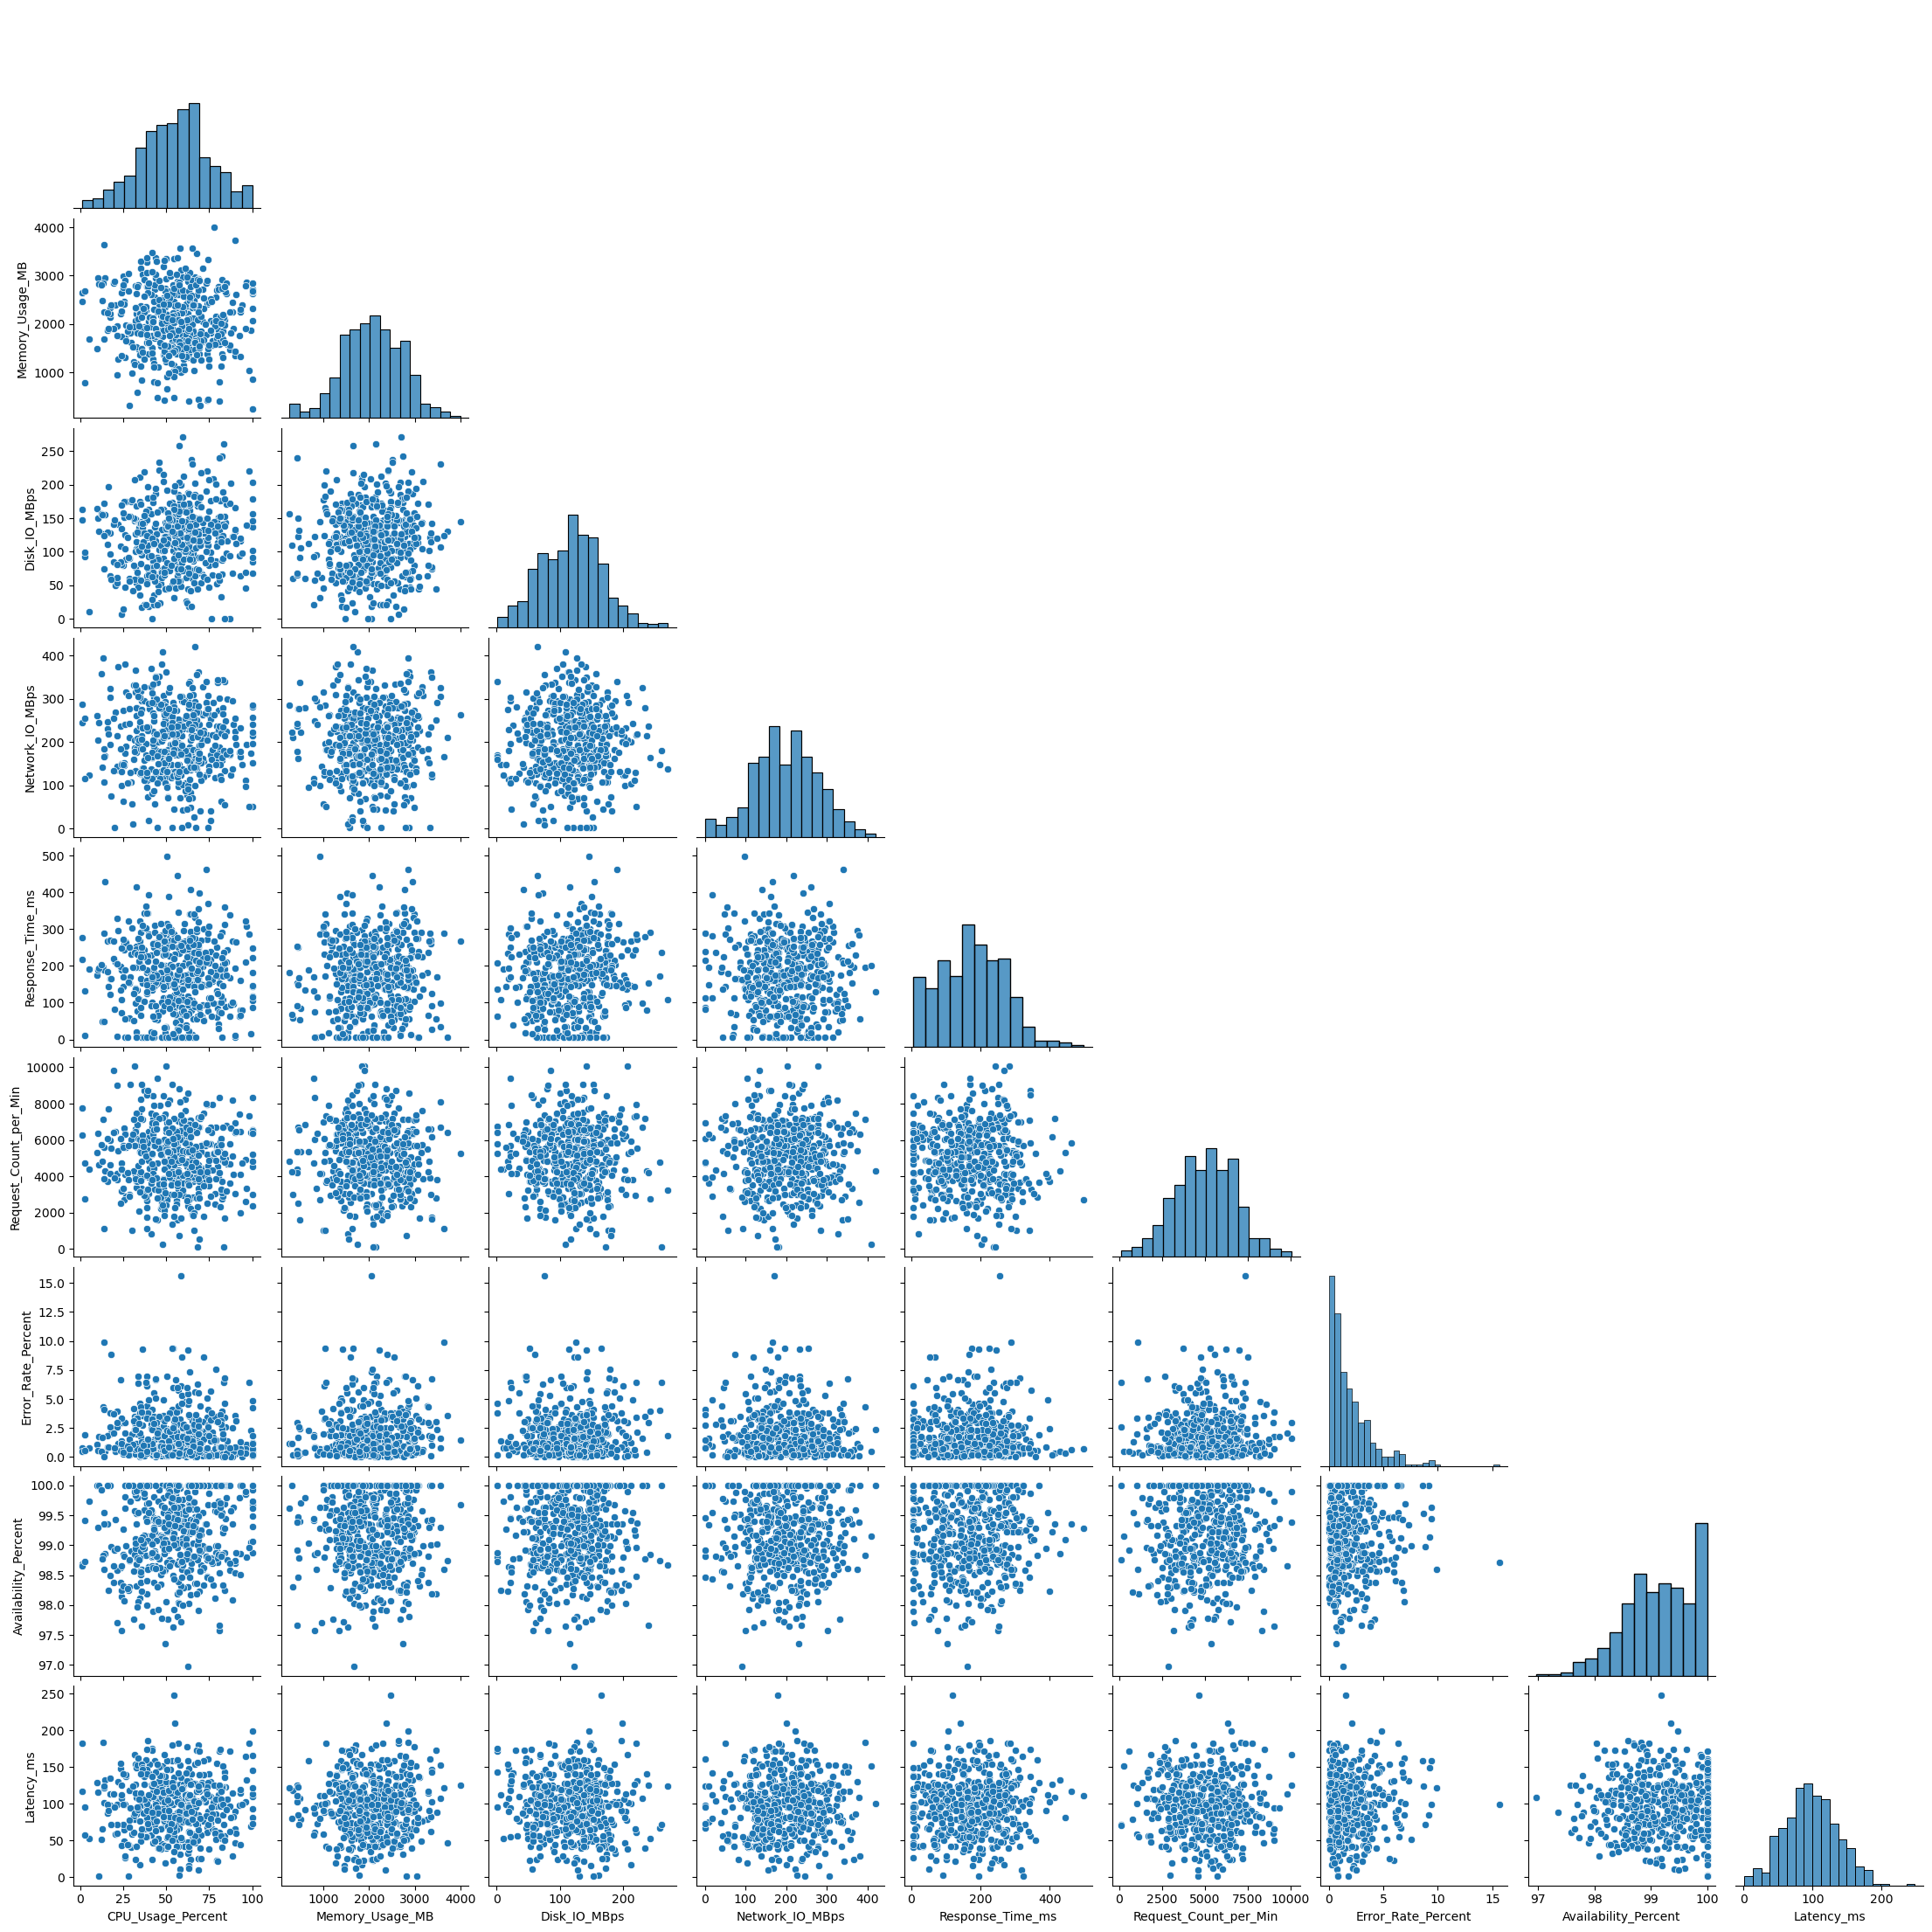

In [12]:
sns.pairplot(
    df.sample(500),
    corner=True
)

plt.show()

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

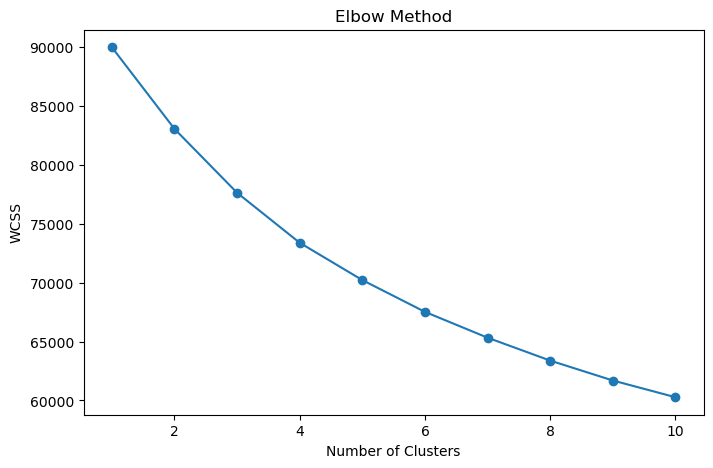

In [14]:
# Elbow Method

wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_data)

    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [ ]:
for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        labels
    )

    print(f"K={k}  Score={score:.4f}")

K=2  Score=0.0780
K=3  Score=0.0824
K=4  Score=0.0772
K=5  Score=0.0747
K=6  Score=0.0751
K=7  Score=0.0748


In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.head())

In [ ]:
'Cluster' in df.columns

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Create Cluster column
df['Cluster'] = kmeans.fit_predict(scaled_data)

print(df.columns)
print(df['Cluster'].value_counts())

In [ ]:
sns.countplot(
    x='Cluster',
    data=df,color="Red"
)

plt.title("Cluster Distribution")
plt.show()

In [ ]:
cluster_profile = df.groupby('Cluster').mean()

cluster_profile

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='CPU_Usage_Percent',
    y='Latency_ms',
    hue='Cluster',
    palette='Set1'
)

plt.show()

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Response_Time_ms',
    y='Error_Rate_Percent',
    hue='Cluster'
)

plt.show()

In [ ]:
df.groupby('Cluster')[[
    'Latency_ms',
    'Error_Rate_Percent',
    'Availability_Percent'
]].mean()